###  all imports 

In [1]:
# imports
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
import sys
import os
import matplotlib.pyplot as plt
from PIL import Image
import io
import cairosvg

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_root)

import pc.data_gen.data_generator as dgen
import pc.data_gen.test_data_generator as tgen
from pc.plot_gen.multi_cat import MultiCatPCPGenerator
from pc.plot_gen.single_cat import SingleCatPCPGenerator
from pc.plot_gen.axes_crop import CroppingProcessor
from pc.plot_gen.cat_sep import CategorySeparator
from pc.data_gen.real_dist_info import extract_distributions_from_excel, extract_dist_plots_from_excel

# paths

#synthetic csvs
data_path = "data/raw_synthetic/training/data_example"
raw_data_path = os.path.join(project_root, data_path)

test_d_path = "data/raw_synthetic/real_inspired_data"
test_data_path = os.path.join(project_root, test_d_path)

#synthetic plots multi categories 
plot_paths = "data/synthetic_plots/training/multi_plot_example"
plot_paths = os.path.join(project_root, plot_paths)

#synthetic plots single category 
splot_paths = "data/synthetic_plots/training/single_plot_example"
splot_paths = os.path.join(project_root, splot_paths)

crop_paths = os.path.join(project_root, "data/synthetic_plots/training/m_crops")
color_sep_paths = os.path.join(project_root, "data/synthetic_plots/training/color_sep")

#json_categroy_sep
all_data_sep = os.path.join(project_root, "data/synthetic_plots/training/color_sep/all_histdata.json")


# visualization method 
def show_images_from_folder(folder_path, title="Images", max_images=4, sort=True):
    image_paths = [
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".svg"))
    ]

    if sort:
        image_paths.sort()

    image_paths = image_paths[:max_images]

    if not image_paths:
        print("No images found in", folder_path)
        return

    cols = 3
    rows = (len(image_paths) + cols - 1) // cols
    plt.figure(figsize=(cols * 4, rows * 4))

    for i, path in enumerate(image_paths):
        ext = os.path.splitext(path)[1].lower()

        if ext == ".svg":
            # Convert SVG to PNG using cairosvg and load via PIL
            try:
                png_data = cairosvg.svg2png(url=path)
                img = Image.open(io.BytesIO(png_data))
                print(img.size)
            except Exception as e:
                print(f"Error loading SVG: {path}", e)
                continue
        else:
            img = Image.open(path)
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(os.path.basename(path))

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

### test_set distriubtion generation using real world distriubtion information 


In [2]:
excel_path = "real_world_dis_info.xlsx"
axes_dist, cat_dist, rows_dist = extract_distributions_from_excel(excel_path)

dgen.generate_synthetic_datasets_from_distributions(
    directory_path="out_comb/synthetic_output13",
    k=15,  # or 5000
    axes_distribution=axes_dist,
    categories_distribution=cat_dist,
    rows_distribution=rows_dist,
    seed=767  # for reproducibility
)

[✓] Generated 15 datasets using real-world distributions.
[✓] Annotations saved to: out_comb/synthetic_output13/annotations.json


Saved out_comb/synthetic_plots13_no_ticks/per_category/image_1_SOXR.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category/image_1_y1hE7.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category/image_1_zdDU.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category_noticks/image_1_SOXR.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category_noticks/image_1_y1hE7.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category_noticks/image_1_zdDU.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category/image_2_QRXC.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category_noticks/image_2_QRXC.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category/image_3_UvLPX.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category/image_3_UTnXwc.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category/image_3_6ayE.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category_noticks/image_3_UvLPX.svg
Saved out_comb/synthetic_plots13_no_ticks/per_category_noticks/image_3_UTnXwc.svg
Saved ou

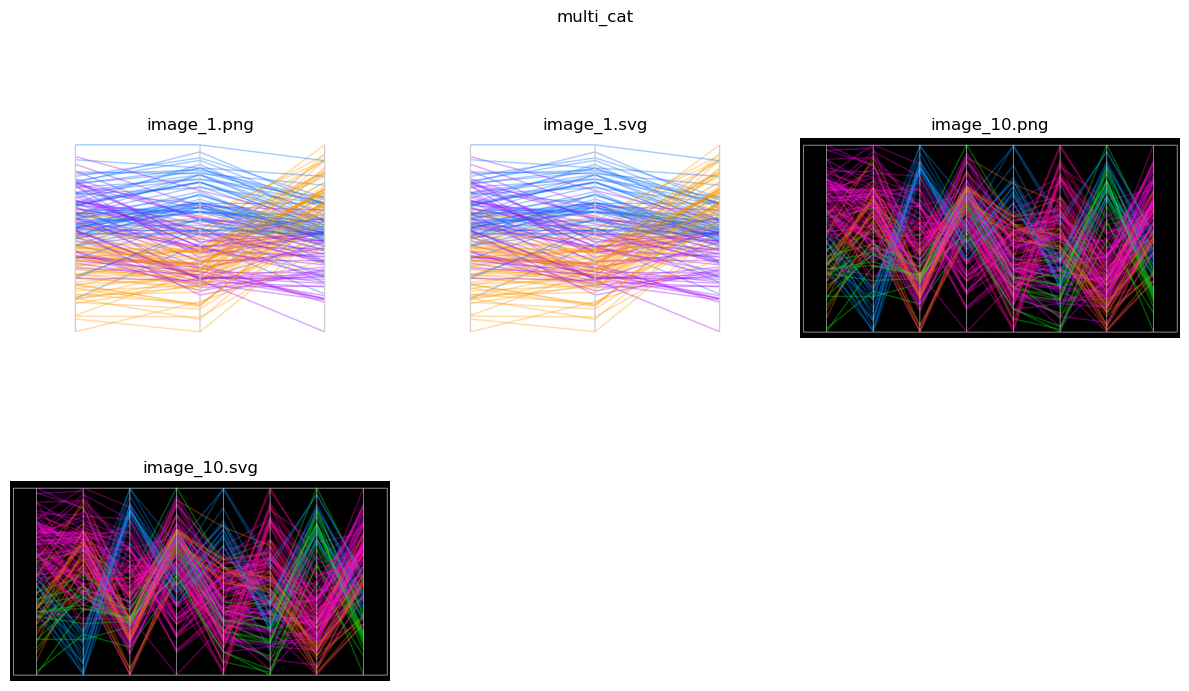

In [2]:

bg_dist, grid_dist,ticks_dist = extract_dist_plots_from_excel("real_world_dis_info.xlsx")
# print(bg_dist)
# print(grid_dist)
# print(ticks_dist)
# Generate plots
plotter = MultiCatPCPGenerator(seed=45345)
plotter.generate_batch(
    input_dir="out_comb/synthetic_output13",
    output_dir="out_comb/synthetic_plots13_1",
    num_files=10,
    background_distribution=bg_dist,
    grid_distribution=grid_dist,
    ticks_labels_distribution=ticks_dist, 
    no_ticks_output_dir="out_comb/synthetic_plots13_no_ticks"
    
)

show_images_from_folder("out_comb/synthetic_plots13_1", title="multi_cat")

### cropping 

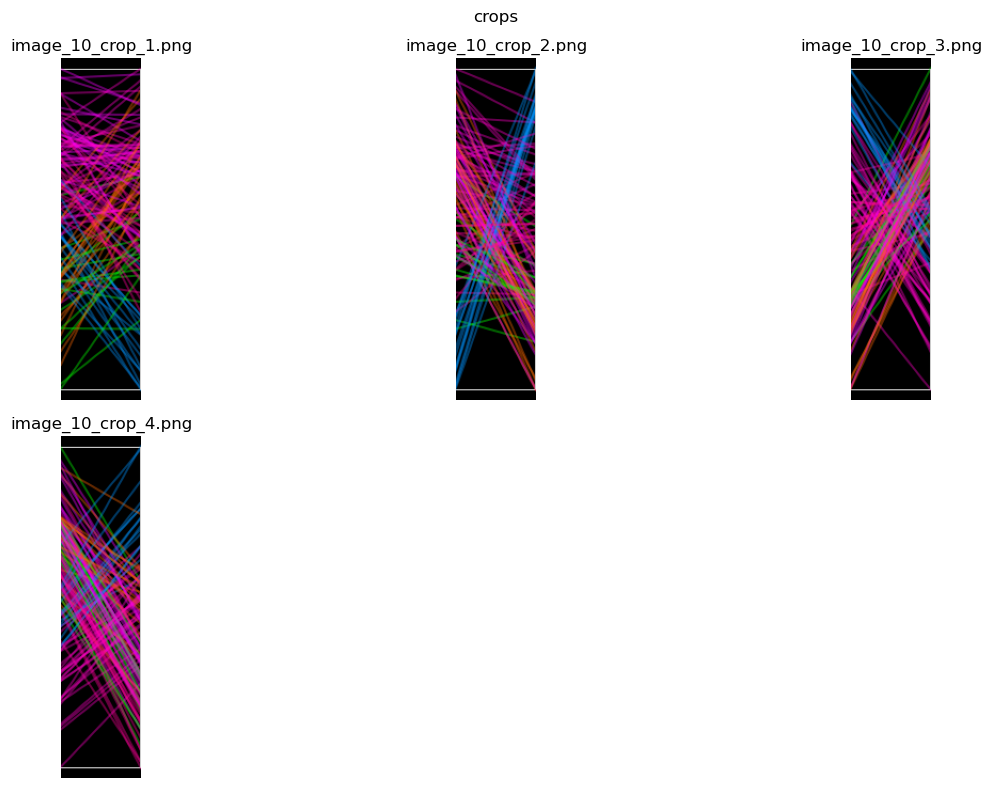

In [3]:
cp = CroppingProcessor()
cp.create_crops("out_comb/synthetic_plots13_no_ticks", "out_comb/cropping_plots_no_ticks")
cp.create_crops("out_comb/synthetic_plots13_1", "out_comb/cropping_plots")
cp.create_crops("out_comb/synthetic_plots13_no_ticks/per_category", "out_comb/cropping_plots_pc")
cp.create_crops("out_comb/synthetic_plots13_no_ticks/per_category_noticks", "out_comb/cropping_plots_pn")
show_images_from_folder("out_comb/cropping_plots_no_ticks", title="crops")

### line data extraction 

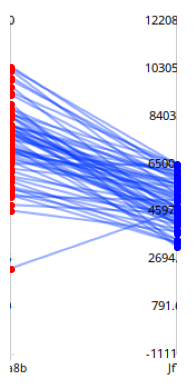

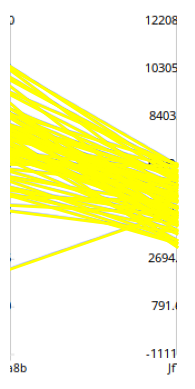

In [9]:
# import json
# import matplotlib.pyplot as plt



# # Files
# json_file = 'out_comb/synthetic_plots13_1/image_3.json'
# filename = "image_3_6ayE_crop_1.png"
# # image_over = 'out_comb/cropping_plots_no_ticks/image_2_crop_1.png'
# image_over = 'out_comb/cropping_plots_pn/image_3_6ayE_crop_1.png'
# # Load the data from image_1.json
# with open(json_file, 'r') as file:
#     data = json.load(file)

# # Derive crop key automatically from filename ("image_1_crop_1.png" -> "crop_1")
# crop_key = filename.split("_crop_")[-1].split(".")[0]   # "1"
# crop_key = f"crop_{crop_key}"

# # Extract the line data
# line_data = data["lines_by_region"][crop_key]

# # Plot image
# img = plt.imread(image_over)
# fig, ax = plt.subplots()
# ax.imshow(img)

# # Draw circles on the line coordinates
# for x1, y1, x2, y2 in line_data:
#     ax.plot(x1, y1, 'ro', markersize=4)  # start point
#     ax.plot(x2, y2, 'bo', markersize=4)  # end point

# plt.axis('off')
# plt.show()



# # Load the image
# img = plt.imread(image_over)
# fig, ax = plt.subplots()
# ax.imshow(img)

# # Draw lines in bright yellow
# for x1, y1, x2, y2 in line_data:
#     ax.plot([x1, x2], [y1, y2], color='yellow', linewidth=2)

# plt.axis('off')
# plt.show()

import json
import matplotlib.pyplot as plt

# Files
json_file = 'out_comb/synthetic_plots13_1/image_3.json'
filename = "image_3_6ayE_crop_2.png"
image_over = 'out_comb/cropping_plots_pc/image_3_6ayE_crop_2.png'

# Load JSON
with open(json_file, 'r') as file:
    data = json.load(file)

# Derive crop key
crop_num = filename.split("_crop_")[-1].split(".")[0]   # "1"
crop_key = f"crop_{crop_num}"

# Derive category key from filename
# "image_3_6ayE_crop_1.png" -> "6ayE"
category_key = filename.split("_")[2]

# Extract line data for that crop & category
line_data = data["lines_by_region"][crop_key][category_key]

# --- Plot points ---
img = plt.imread(image_over)
fig, ax = plt.subplots()
ax.imshow(img)

for x1, y1, x2, y2 in line_data:
    ax.plot(x1, y1, 'ro', markersize=4)  # start point
    ax.plot(x2, y2, 'bo', markersize=4)  # end point

plt.axis('off')
plt.show()

# --- Plot connecting lines ---
img = plt.imread(image_over)
fig, ax = plt.subplots()
ax.imshow(img)

for x1, y1, x2, y2 in line_data:
    ax.plot([x1, x2], [y1, y2], color='yellow', linewidth=2)

plt.axis('off')
plt.show()


### Category separation from crops 

 Saved masks → /home/poonam/myworkspace/PaCoNet/data/synthetic_plots/training/color_sep/all_histdata.json
Saved colors → /home/poonam/myworkspace/PaCoNet/data/synthetic_plots/training/color_sep/color.json


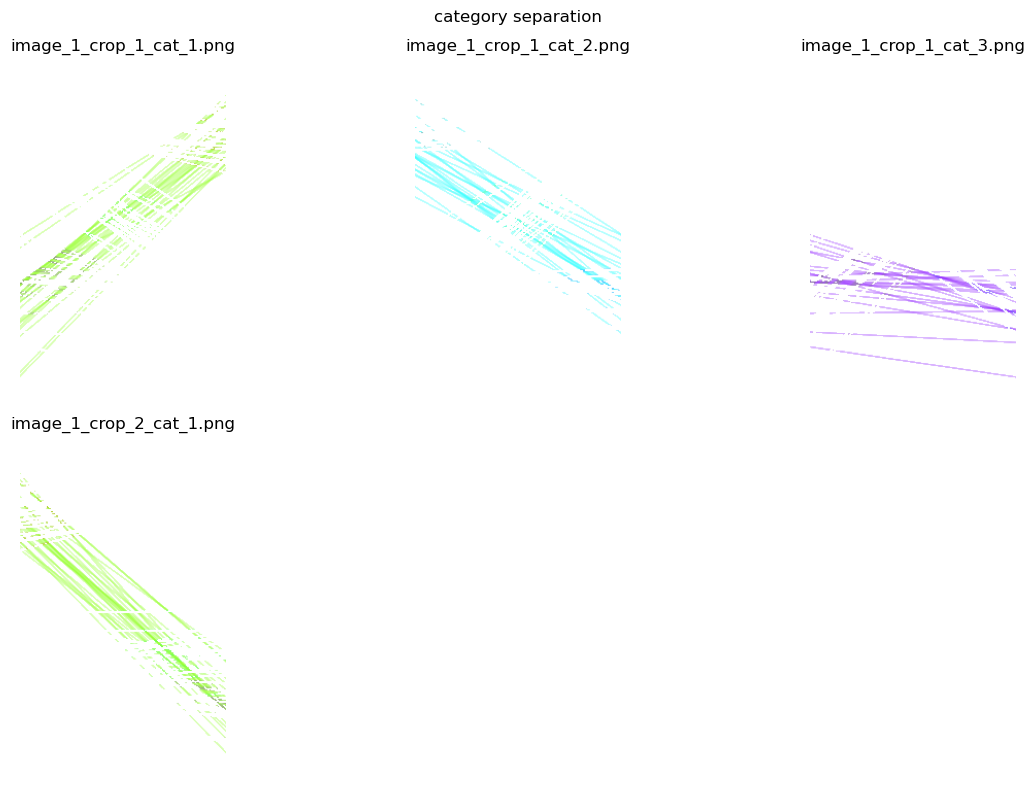

In [5]:
sep = CategorySeparator(crop_paths, line_json)  # No JSON path given

sep.separate_by_hist_peaks(output_dir=color_sep_paths)

show_images_from_folder(color_sep_paths, title="category separation")

In [ ]:
# Example usage
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1,1]
])


In [ ]:
import custom_dataset_unet as cus
dataset = cus.CustomHSVMatchingDatasetSDMask(
    input_json = "dataset/training_data/data04_color_thres/line_with_sepimg.json", #cls_line_json_path 
    ground_truth_json= "dataset/training_data/data04_gt_plots_crops/gt_line_color.json",
    input_dir="dataset/training_data/data04_cluster_thres",
    ground_truth_dir="dataset/training_data/data04_gt_plots_crops",
    mask_dir="dataset/training_data/data04_gt_plots_crops_masks",
    transform=transform,
    hsv_tolerance=0.1  # Adjust as needed
)

In [ ]:
# unet inference 


tester = UNetTester(config, test_config)

# Run just one test (color)
tester.run(
    input_dir=test_config.m_color_sep_plots,
    output_dir=test_config.m_color_denoised_plots,
    description="Multi-color separation"
)

### real_world_dataset attributes analysis 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Load Excel file
excel_path = "real_world_data_information.xlsx"
df_info = pd.read_excel(excel_path, sheet_name="Sheet1")

# Clean column names
df_info.columns = [col.strip().replace('\n', ' ') for col in df_info.columns]

# Attributes to plot directly from the Excel
attributes_to_plot = [
    "Number of Vertical Axes (Features)",
    "Number of lines/rows (approximately)",
    "Number of Categories (groups/polylines)"
]

# --- Parse Tick Labels column ---
def parse_ticks(entry):
    if pd.isna(entry):
        return []
    try:
        parsed = ast.literal_eval(str(entry))
        return parsed if isinstance(parsed, list) else []
    except:
        return []

tick_lists = df_info["Tick labels for vertical axes"].apply(parse_ticks)

tick_ranges = []
for entry in tick_lists:
    if isinstance(entry, list):
        if all(isinstance(i, list) and len(i) == 2 for i in entry):
            for pair in entry:
                try:
                    min_val = float(str(pair[0]).split()[0])
                    max_val = float(str(pair[1]).split()[0])
                    tick_ranges.append((min_val, max_val))
                except:
                    continue
        elif len(entry) == 2:
            try:
                min_val = float(str(entry[0]).split()[0])
                max_val = float(str(entry[1]).split()[0])
                tick_ranges.append((min_val, max_val))
            except:
                continue

tick_df = pd.DataFrame(tick_ranges, columns=["min", "max"])
tick_df["range"] = tick_df["max"] - tick_df["min"]

# --- Combine all attributes ---
all_attributes = [
    ("Number of Vertical Axes (Features)", df_info["Number of Vertical Axes (Features)"]),
    ("Number of lines/rows (approximately)", df_info["Number of lines/rows (approximately)"]),
    ("Number of Categories (groups/polylines)", df_info["Number of Categories (groups/polylines)"]),
    ("Tick Label Minimum Values", tick_df["min"]),
    ("Tick Label Maximum Values", tick_df["max"]),
    ("Tick Label Ranges", tick_df["range"]),
]

# --- Plot all distributions ---
plt.figure(figsize=(15, 24))
for i, (title, data_series) in enumerate(all_attributes, 1):
    plt.subplot(6, 1, i)
    sns.histplot(data_series.dropna(), kde=True, bins=15)
    plt.title(f"Distribution of {title}")
    plt.xlabel(title)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [12]:
# requirements: pandas, matplotlib, openpyxl
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

excel_path = "real_world_dis_info.xlsx"          # adjust path if needed
out_pdf    = "all_distributions_histograms.pdf"  # all plots in one multi-page PDF

# --- load ---
df = pd.read_excel(excel_path)

# --- helpers ---
def find_col_exact(df, name):
    for col in df.columns:
        if str(col).strip().lower() == name.strip().lower():
            return col
    return None

def find_col_fuzzy(df, patterns):
    for col in df.columns:
        lc = str(col).strip().lower()
        for pat in patterns:
            if isinstance(pat, str):
                if pat in lc:
                    return col
            else:
                if pat.search(lc):
                    return col
    return None

def to_yes_no(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    if s in {"1","true","yes","y","t"}: return "Yes"
    if s in {"0","false","no","n","f"}: return "No"
    return np.nan

# --- column detection ---
col_vertical_axes  = find_col_fuzzy(df, ["number of vertical axes","vertical axes","num vertical","vertical_axis","verticalaxis"])
col_rows_raw       = find_col_fuzzy(df, ["number of rows","rows", re.compile(r"\brows?\b"), "n rows"])
col_num_categories = find_col_fuzzy(df, ["number of categories","num categories","categories", re.compile(r"\bcats?\b")])

# Background RGB as a single numeric column
col_bg_rgb = find_col_exact(df, "Background RGB")
if col_bg_rgb is None:
    col_bg_rgb = find_col_fuzzy(df, ["background rgb","bg rgb","rgb"])

col_grid  = find_col_fuzzy(df, ["grid","has grid"])
col_ticks = find_col_fuzzy(df, ["presence of ticks","has ticks","ticks"])

# --- working data ---
data = pd.DataFrame(index=df.index)

data["vertical_axes"]  = pd.to_numeric(df[col_vertical_axes], errors="coerce") if col_vertical_axes else np.nan
rows_raw               = pd.to_numeric(df[col_rows_raw], errors="coerce") if col_rows_raw else pd.Series([np.nan]*len(df), index=df.index)
data["num_categories"] = pd.to_numeric(df[col_num_categories], errors="coerce") if col_num_categories else np.nan
data["background_rgb"] = pd.to_numeric(df[col_bg_rgb], errors="coerce") if col_bg_rgb else np.nan

# bin rows: [0,50), [50,100), [100,150), [150,200), [200,250), [250,300), (300, ∞)
edges  = [0,50,100,150,200,250,300, np.inf]
labels = [1,2,3,4,5,6,7]
data["rows_raw"]      = rows_raw
data["rows_bin_1to7"] = pd.cut(rows_raw, bins=edges, labels=labels, right=False, include_lowest=True).astype("float").astype("Int64")

# binary flags
data["grid"]  = df[col_grid].apply(to_yes_no)  if col_grid  else np.nan
data["ticks"] = df[col_ticks].apply(to_yes_no) if col_ticks else np.nan

# --- plotting: each chart its own figure; saved into a single PDF ---
with PdfPages(out_pdf) as pdf:
    # Number of vertical axes (histogram)
    v = data["vertical_axes"].dropna()
    if len(v) > 0:
        plt.figure(); plt.hist(v, bins="auto")
        plt.title("Histogram: Number of vertical axes")
        plt.xlabel("Number of vertical axes"); plt.ylabel("Count")
        plt.tight_layout(); pdf.savefig(); plt.close()

    # Number of categories (histogram)
    v = data["num_categories"].dropna()
    if len(v) > 0:
        plt.figure(); plt.hist(v, bins="auto")
        plt.title("Histogram: Number of categories")
        plt.xlabel("Number of categories"); plt.ylabel("Count")
        plt.tight_layout(); pdf.savefig(); plt.close()

    # Rows (binned 1..7) as histogram with fixed centers on integers
    v = data["rows_bin_1to7"].dropna().astype(int)
    if len(v) > 0:
        plt.figure(); plt.hist(v, bins=np.arange(0.5, 7.5+1e-9, 1))
        plt.title("Histogram: Number of rows (binned 1–7)")
        plt.xlabel("Rows bin (1:0–50, 2:50–100, 3:100–150, 4:150–200, 5:200–250, 6:250–300, 7:>300)")
        plt.ylabel("Count")
        plt.tight_layout(); pdf.savefig(); plt.close()

    # Background RGB (single numeric column: values should be 0, 128, or 255)
        # Background RGB (exact values: 0, 128, 255)
    v = data["background_rgb"].dropna()
    if len(v) > 0:
        counts = v.value_counts().sort_index()
        plt.figure()
        plt.bar(counts.index.astype(str), counts.values)
        plt.title("Background RGB")
        plt.xlabel("RGB value")
        plt.ylabel("Count")
        plt.tight_layout()
        pdf.savefig()
        plt.close()

    # Grid / Ticks (bar charts)
    for ch, label in [("grid","Grid present"), ("ticks","Ticks present")]:
        v = data[ch].dropna()
        if len(v) > 0:
            counts = v.value_counts()
            plt.figure(); plt.bar(counts.index.astype(str), counts.values)
            plt.title(f"{label}: Yes/No counts")
            plt.xlabel(label); plt.ylabel("Count")
            plt.tight_layout(); pdf.savefig(); plt.close()

print(f"Saved: {Path(out_pdf).resolve()}")


Saved: /home/poonam/myworkspace/PaCoNet/notebooks/all_distributions_histograms.pdf


In [31]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Load Excel
df = pd.read_excel("real_world_dis_info.xlsx")

# --- helpers ---
def find_col_fuzzy(df, patterns):
    for col in df.columns:
        lc = str(col).strip().lower()
        for pat in patterns:
            if isinstance(pat, str):
                if pat in lc:
                    return col
            else:
                if pat.search(lc):
                    return col
    return None

def find_col_exact(df, name):
    for col in df.columns:
        if str(col).strip().lower() == name.strip().lower():
            return col
    return None

def to_yes_no(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    if s in {"1","true","yes","y","t"}: return "Yes"
    if s in {"0","false","no","n","f"}: return "No"
    return np.nan

# Detect columns
col_vertical_axes  = find_col_fuzzy(df, ["number of vertical axes","vertical axes","num vertical"])
col_rows_raw       = find_col_fuzzy(df, ["number of lines","lines", re.compile(r"\brows?\b")])
col_num_categories = find_col_fuzzy(df, ["number of categories","num categories","categories"])
col_bg_rgb         = find_col_exact(df, "Background RGB") or find_col_fuzzy(df, ["background rgb","bg rgb","rgb"])
col_grid           = find_col_fuzzy(df, ["grid","has grid"])
col_ticks          = find_col_fuzzy(df, ["presence of ticks","has ticks","ticks"])

# Build data
data = pd.DataFrame(index=df.index)
data["vertical_axes"]  = pd.to_numeric(df[col_vertical_axes], errors="coerce") if col_vertical_axes else np.nan
data["lines"]       = pd.to_numeric(df[col_rows_raw], errors="coerce") if col_rows_raw else np.nan
data["num_categories"] = pd.to_numeric(df[col_num_categories], errors="coerce") if col_num_categories else np.nan
data["background_rgb"] = pd.to_numeric(df[col_bg_rgb], errors="coerce") if col_bg_rgb else np.nan

# Bin rows
edges  = [0,50,100,150,200,250,300, np.inf]
labels = [1,2,3,4,5,6,7]
data["rows_bin"] = pd.cut(data["lines"], bins=edges, labels=labels, right=False, include_lowest=True).astype("float").astype("Int64")

# Binary flags
data["grid"]  = df[col_grid].apply(to_yes_no)  if col_grid  else np.nan
data["ticks"] = df[col_ticks].apply(to_yes_no) if col_ticks else np.nan

# Custom bin labels
bin_label_map = {
    1: '0-50',
    2: '50-100',
    3: '100-150',
    4: '150-200',
    5: '200-250',
    6: '250-300',
    7: '300+'
}
data["rows_bin_label"] = data["rows_bin"].map(bin_label_map)

# --- plotting ---
sns.set(style="whitegrid")

fig, axes = plt.subplots(6, 1, figsize=(6, 28))  # 7 plots

# 1. Number of vertical axes
sns.histplot(data=data, x="vertical_axes", kde=True, ax=axes[0])
axes[0].set_title("Distribution of Number of Vertical Axes")

# 2. Number of rows (raw)
sns.histplot(data=data, x="lines", kde=True, ax=axes[1])
axes[1].set_title("Distribution of Number of Lines")

# # 3. Number of rows (binned with labels)
# sns.countplot(data=data, x="rows_bin_label", order=bin_label_map.values(), ax=axes[2])
# axes[2].set_title("Distribution of Number of Rows (binned)")
# axes[2].set_xlabel("Rows bin")

# 4. Number of categories
sns.histplot(data=data, x="num_categories", kde=True, ax=axes[2])
axes[3].set_title("Distribution of Number of Categories")

# 5. Background RGB
sns.countplot(data=data, x="background_rgb", ax=axes[3])
axes[3].set_title("Distribution of Background RGB Values")

# 6. Grid
sns.countplot(data=data, x="grid", ax=axes[4])
axes[4].set_title("Distribution of Grid Presence (Yes/No)")

# 7. Ticks
sns.countplot(data=data, x="ticks", ax=axes[5])
axes[5].set_title("Distribution of Ticks Presence (Yes/No)")

plt.tight_layout()
out_path_rows_hist = "seaborn_distributions_rows_hist.png"
plt.savefig(out_path_rows_hist, dpi=300)
plt.close(fig)

print(f"Saved plot to {out_path_rows_hist}")


Saved plot to seaborn_distributions_rows_hist.png
